# Data Processing

## Processing

*The set of operations to be performed on your dataset to extract higher-level information*.

**Q**: How does processing scale with the dataset size/ task complexity / ..:?

Processing can be seen as the sequential execution of a set of instructions by the CPU, where both the data and the instructions are kept in memory. The CPU follows a fetch-decode-execute cycle for each instruction:
- **Fetch**: retrieving isntruction from memory
- **Decode**: interpreting of the instruction
- **Execute**: execution of the instruction.

Thus, the **CPU processing time** is the overall time needed to execute the whole set of instructions and it depends on:
- the complexity of the instruction set
- the CPU clock frequency
- the overheads induced by the communication with registers and memory.

### Pipelining

*Instruction Pipelining* aims to enable multiple instructions to be run *concurrently* on the same ALU.

### Multi-Processing Architectures 

*Multi-Core CPUs*:
- $n_{\text{tot}}$(PUs in OS) $=$ 
    - $n$(sockets) (CPUs) $\times$
    - $n$(cores per socket) (physical PUs) $\times$ 
    - $n$(threads per core) (n of logical PUs per core)

*Parallelism* refers to the idea of exploiting multi-processing architectures in order to solve complex problems:
1. Data-level parallelism (DLP): Many data items (records) that can be operated on at the same time (i.e. split the data and run a task on all elements in parallel).
2. Task-level parallelism (TLP): Multiple sub-tasks (or *threads*) of a process that can operate independently and *largely* in parallel (i.e. split task into sub-tasks and run them in parallel).

### Parallel Processing

Simultaneous execution of a single job by subdiving in $n$ sub-tasks execute across $m$ CPUs/cores.

**GOAL**: To reduce the computing time of the job.

When multiple instructions and multiple data items are run in parallel we are dealing with an **Embarrassingly parellel** problem.

### Concurrency and Parallelism

**PROCESS**: An instance of a program in execution, an **independenty entit**y** with executable code and memory.

**THREAD**: A **basic unit** of CPU utilization, consisting of a program counter, memory, set of registers. A **part of a process**.

Thus, each process can be comprised of multiple threads. Certainly to each process correspond a set of instructions. It is the sub-sets of  possible instructions that make up each thread (such that we have a multi-threaded process).

Multi-threaded processes share a "global" memory with commond resources (code, data, files) and have an independent set of registers, memory and execution state per each thread.

**CONCURRENCY**: When multiple tasks are *in progress* at the same time. Tasks can start/run/stop independently and executed out of order.
(For single core tasks.)

**PARALLELISM**: When multiple tasks are in *execution* at the same time. (For multiple core tasks.)

**MULTI-TASKING**: Execution of multiple *concurrent* tasks.
Example:
- OS instructs CPU to share its time between the various tasks. How?
    - Pre-emptive scheduling, when alternating between the N tasks sharing equally the CPU time
    - Collaborative scheduling, when the OS switch processes only upon the active one release control to the scheduler.

Thus, depending on the architecture and OS, MultiThreading occur:
- Concurrently, on single-core CPUs with multi-tasking OS
- In parallel, on 2+ cores CPUs.

### Race Conditions

Possible issue of multi-threaded execution:
- Example: Memory is shared across threads, then the concurrent or simultaneous execution of 2 instructions on shared data may create inconsistencies across threads.

**RACE CONDITION**: When a given resource (e.g. the same data in memory) is accessed concurrently by multiple threads AND the outcome depends on the particular order in which the access takes place.

Thus, threads must be synchronized. 

------
In python:
- **Threading**:
    - Threads share the same memory and can write to and read from shared variables.
    - Threads are only executed concurrently

- **Multiprocessing**:
    - Every process has its own memory space.
    - Every process can contain one or more subprocesses.
    - Achieve parallelism by taking advantage of multi-core machines.

### Distributed Processing

As processing can scale with the nunber of processing units $n$(provided it is parallelizable at least up to the $n$-th processing unit). **Scalability** in terms of processes can occur either **vertically (up)** by increasing the capacity/prformance of the available resources (better HW) or **horizontally (out)** by adding more resources (more HW).

Thus, architecture structures vary depending on the way computing resources are shared:
- **Shared Memory MultiProcessor (SMP)**: When memory is shared across a number of parallel CPUs.
- **Distributed Memory MultiProcessor (Cluster)**: Each processor is associated with its own memory (making up a *node*), s.t. all nodes are connected via high speed network. Complexity in the communication across the individual units.

![Cluster](Images/Cluster.png "Cluster")
![SMP](Images/SMP.png "SMP")

#### Distributed Computing: Cluster

The objective is to distribute the processing across multiple nodes of a set of computing resources linked together by fast speed networks. 

![One Nodes](Images/One_node.png "One Node")

Nodes share computational workload as a "virtual massive computer", exposed to the user as a single system:
- **Head Node**: It is the access point to the cluster for the clients, distributing the workload to the *computing ndoes*
- **Computing Nodes**: They are the nodes in which the actual processing is executed (Not visible by users, accessed only via the *high speed network*).
- **Interactive Nodes**: They are accessible to users as standard computers and are used for testing, storage access and launching jobs. 
- **Specialized Nodes**: They are the nodoes with specific hardware capabilities for *computing* or *storage*.

**BATCH SYSTEMS** are used by users to schedule and submit jobs to a cluster, each job including:
1. An executable (program) + optional arguments (e.g. # CPUs, memory)
2. Info on potential requirements (e.g. libraries).

When the job starts (when possible w.r.t. a queue and available resources), the tasks contained in the job's instructions are dispached on the computing nodes for execution.

## Map-Reduce & Hadoop

### Hadoop

**Hadoop**, born in 2006 and regarded as the main framework for storage and parallel distributed processing of BigData, it was designed to efficiently scale with the number of computing resources (horizontal scaling).

DFSs architecture can be seen in the following image. Basically given the requests sent from a *Client*, they are recieved by a *Name Node*, which are manages and provides the information to proceed (or block) the operation (i.e. writing or reading (in) a filw). The relevant *Data Node*(s) can be accessed directly from the Client by using the metadata about the content of the Data Nodes provided by the Name Node. *Secondary Name Nodes* are used for checkpoints (i.e. metadata backups).

![HDFS Schema](Images/hdfs.png "HDFS Scherma")

### Map-Reduce

Map-Reduce is a paradigm providing a programming model for distributed processing in Hadoop based mainly on the **Map** and the **Reduce** phases:
1. **MAP**: 
    1. Split the input data into a series of *input* <key, value> pairs. 
    2. Process each <key, value> pairs independently and return a list of *intermendiate* <key, value> pairs.
2. **REDUCE**: Take as input the list of intermediate  <key, value> pairs, and run *aggregation* of the values from all pairs with the same key to produce a final list.

Essentially by assigning *keys* to *values* we can process components with different keys in parallel then reduce the components by assigning a new value, given by the result of the processing, to each key, such that operations will occur within values with the same key.

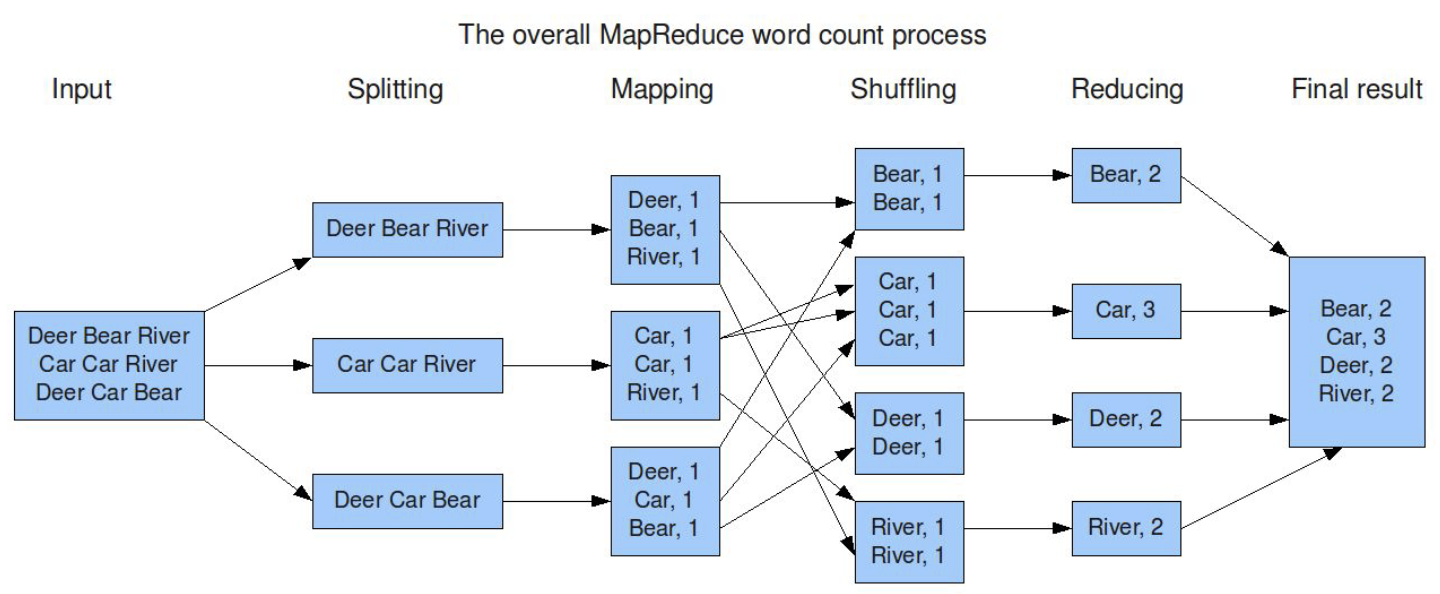

### Map-Reduce in Hadoop

1. Data is read from the DFS, partitioned among a set of computing nodes in the cluster and sent to them as a set of key-value pairs.
2. The Map tasks process the input records **independently of each other** and produce intermediate results as key-value pairs.
3. The intermediate results are **stored on the local disk of the node** running the Map task.
4. When al Map tasks are completed, the Reduce phase begins with the **shuffleand sort** step in which intermediate data is sorted by the key and the key-value pairs are grouped and shuffled to the reduce tasks. 
5. The reduce tasks take the key-value pairs **grouped by the key** and run the reduce function for each group of key-value pairs.

### YARN

The **Cluster Resource Manager** (takes the role of the "OS" for Hadoop) manages the execution and scheduling of jobs. The components of YARN (Yet Another Resource Negotiator) are:
+ **Resource Manager (RM)**: **Assigns** of computing resources to applications (via the *Scheduler* and Applications Manager).
+ **Applicatio Master (AM)**: **Negotiates** resources with the RM and works with the NMs to **execute** and **monitor** the tasks.
+ **Node Manager (NM)**: **Manages** the user processes on each machine (node).
+ **Container**: VM with the **set of resources** allocated by the RM (e.g. memory, CPU) to run a specific task.

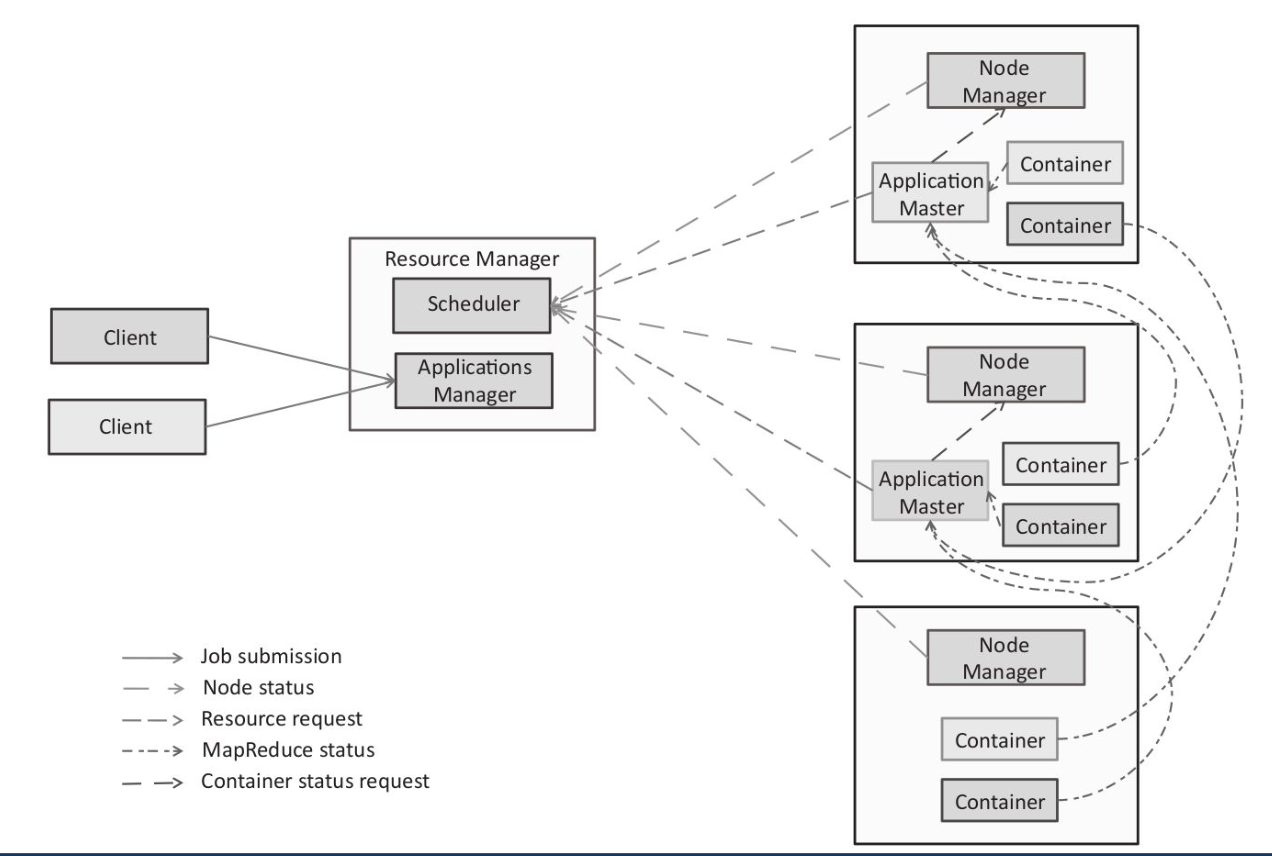

## Spark

Spark (open source cluster computing framework for data analytics, originally developed at UC Berkeley in 2009) deals with applications using a **Master/Slave architecture**.
1. A **Spark Application** (job?) is submitted
2. A **Driver** (application's *driver process* responsible for converting a user application into smaller execution units (tasks), and for distributing and scheduling tasks across the executors) is created.
3. Spark Driver creates a **Spark Context** for each individual Spark Application. It allows the Application to access the Cluster resources with the help of the **Resource Manager**.
4. Together with the Driver, a set of **Executors** are created on the clusters' nodes. Each Executor is responsible for executing the tasks assigned by the Driver, and for reporting the state of the computation back to the driver node.

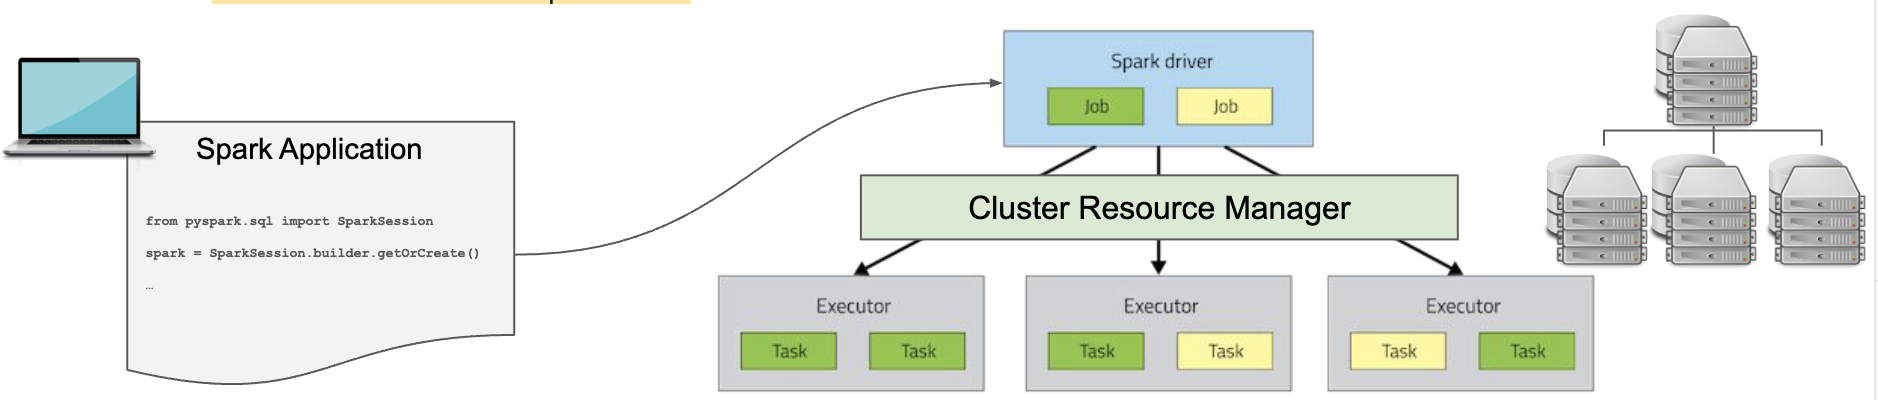

### Cluster Manager
Driver and Executors live in **Java Virtual Machines** (JVMs) within the **worker nodes**. One node may contain several executors (not vice-versa), see image:

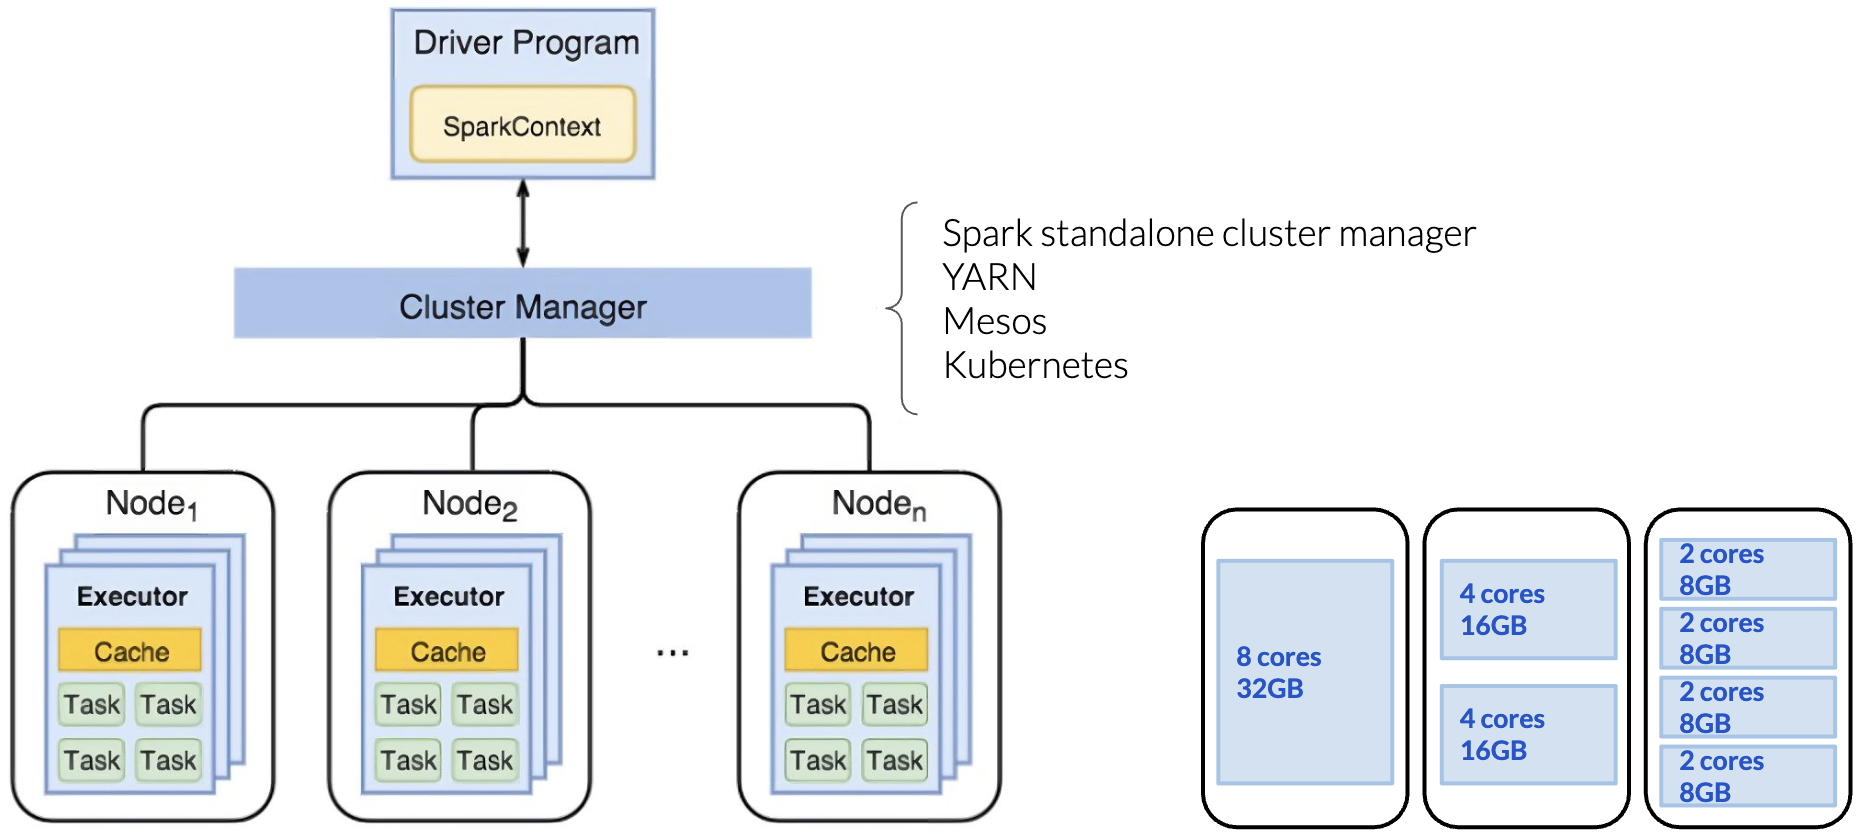

### RDD

Resilient Distributed Dataset (RDD) refers to Spark's low-level data abstraction that describes an **immutable, partitioned collection of records** that can be **operated on in parallel**.
1. Data is stored as a colletion of Java/Python objects (unstructured).
2. Split into partitions and hosted within the executors.
+ Spark can keep an RDD loaded in-memory throughout the life of an application.
+ RDDs are immutable: no chanfes are applied across the application.
+ Fault-tolerant: the RDD contains all the dependencies to recover from a partition loss.

### Transformations & Actions

**Transformations**: Operations (such as map, filter, join, union) that act on the RDD and produce a new RDD containing the result. To understand how transformations work we must distinguish among two types of dependencies across partitions
- *narrow* dependencies: input partition contributes to **only one** output partition
- *wide* dependencies: input partitions contribute to **many** output partitions (*shuffling*).

**Actions**: Operations (such as reduce, first, count) that return a value as the result of a computation on an RDD.

One first runs the transformation, which is *lazy* and will not take place until triggered using an action.